In [181]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, ridge_regression

from xgboost import XGBRegressor

<h2 align="center" style="color:Green">Data Loading</h2>

In [182]:
df = pd.read_excel(r"D:\AI-engineer Study\Projects\Project 7 Premium Prediction ver1\data\premiums.xlsx")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [183]:
df.shape

(50000, 13)

In [184]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='str')

In [185]:
df.columns.str.replace(" ", "_").str.lower()

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='str')

In [186]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [187]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='str')

<h2 align="center" style="color:green">Exploratory Data Analysis & Data Cleaning</h2>

### Handle missing values

In [188]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [189]:
df.dropna(inplace=True)
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handle duplicate

In [190]:
if df.duplicated().sum() > 0:
    print(f"Before drop duplicate: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)
    print(f"After drop duplicate: {df.duplicated().sum()}")
else:
    print(f"No duplicate: {df.duplicated().sum()}")

No duplicate: 0


In [191]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


#### Data Cleaning: number_of_dependants

In [192]:
df.loc[df['number_of_dependants'] < 0]['number_of_dependants'].unique()

array([-3, -1])

We can see some negative values in number_of_dependants. We can replace them with positive numbers

In [193]:
df['number_of_dependants'] = np.abs(df['number_of_dependants'])

In [194]:
df.loc[df['number_of_dependants'] < 0]['number_of_dependants'].unique()

array([], dtype=int64)

In [195]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.717284,23.021150,15766.810189
std,15.000378,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


## 1. Numeric Columns
### Univariate Analysis: Numeric Columns
#### Box plots for numeric columns

In [196]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

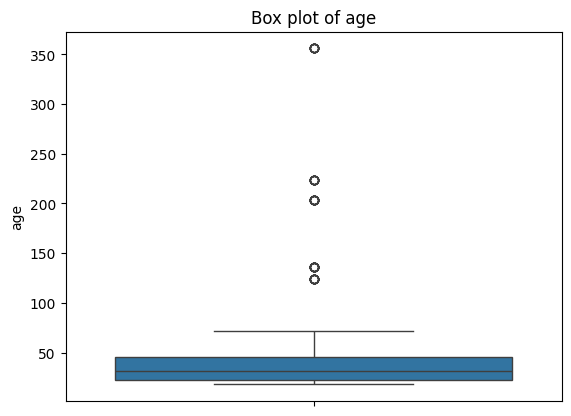

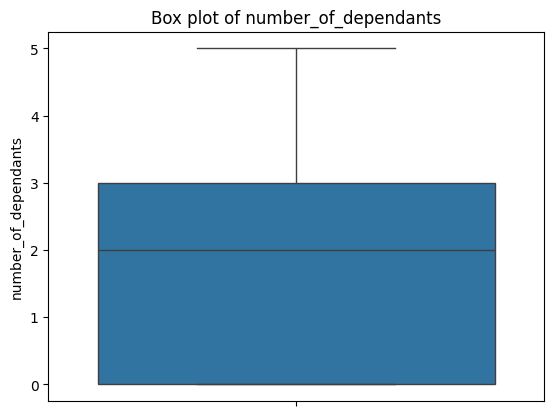

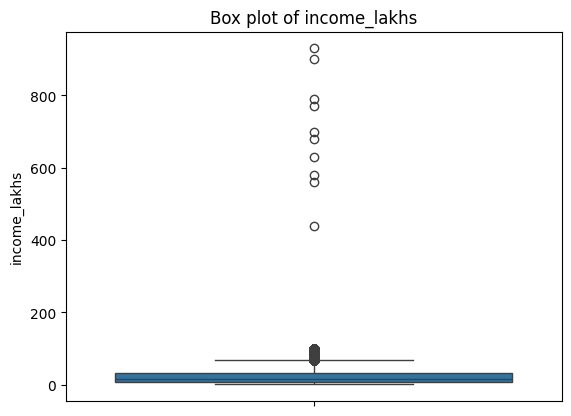

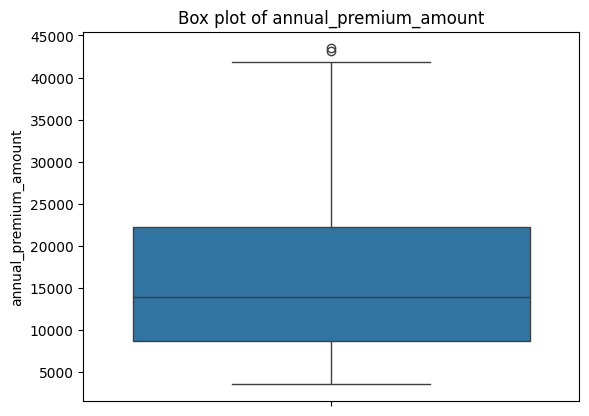

In [197]:
for col in numeric_columns:
    sns.boxplot(data=df, y=col)
    plt.title(f"Box plot of {col}")
    plt.show()

### Outlier Treatment: Age Column

In [198]:
df.loc[df['age'] > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [199]:
df.loc[df['age'] > 100].shape[0]

58

In [200]:
df1 = df.loc[df['age'] <= 100]
df1.shape[0]

49918

In [201]:
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


### Outlier Treatment: Income Column

In [202]:
def get_iqr_bound(col):
    q1, q3 = col.quantile([0.25, 0.75])
    IQR = q3 - q1
    upper_bound = q3 + (1.5 * IQR)
    lower_bound = q1 - (1.5 * IQR)
    return lower_bound, upper_bound

lower, upper = get_iqr_bound(df1['income_lakhs'])
lower, upper

(-29.0, 67.0)

In [203]:
df1.loc[df1['income_lakhs'] > upper].shape[0]

3559

There are many legitimate records that we will get rid of if we use IQR bounds method. Hence after discussion with business we decided to use a simple quantile bound 

In [204]:
quantile_thresold = df1['income_lakhs'].quantile(0.999)
quantile_thresold

np.float64(100.0)

In [205]:
df1.loc[df1['income_lakhs'] > quantile_thresold].shape[0]

10

In [206]:
df2 = df1.loc[df1['income_lakhs'] <= quantile_thresold].copy()
df2.shape

(49908, 13)

In [207]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


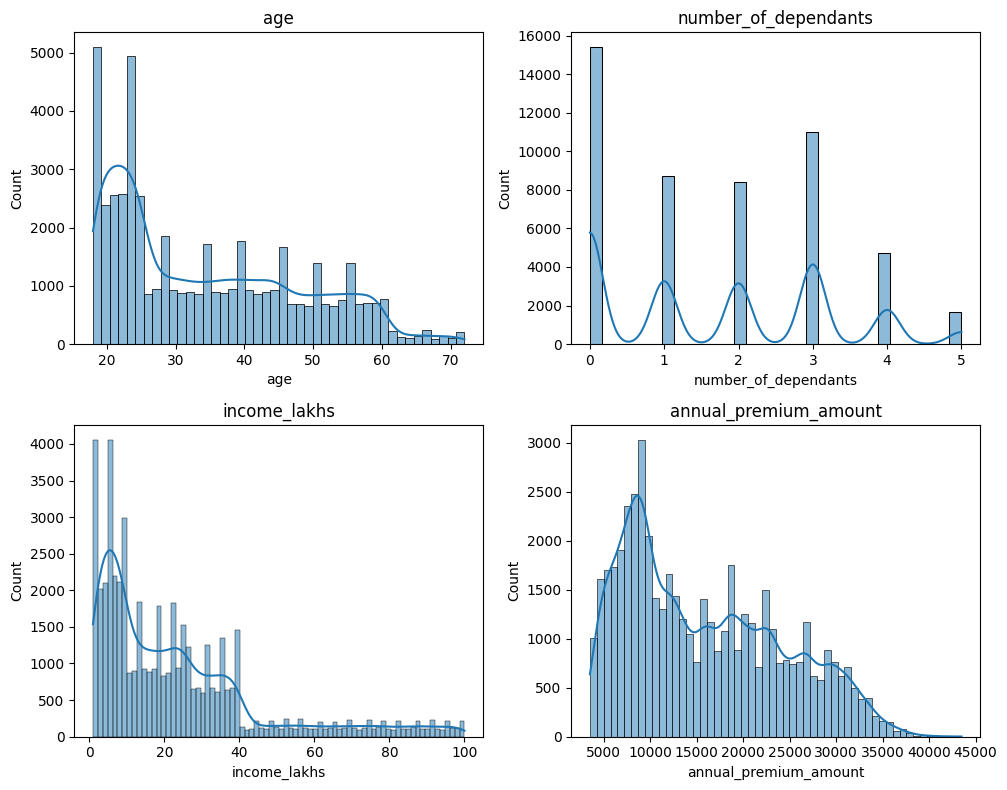

In [208]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.histplot(df2[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

### Bivariate Analysis: Numeric Columns

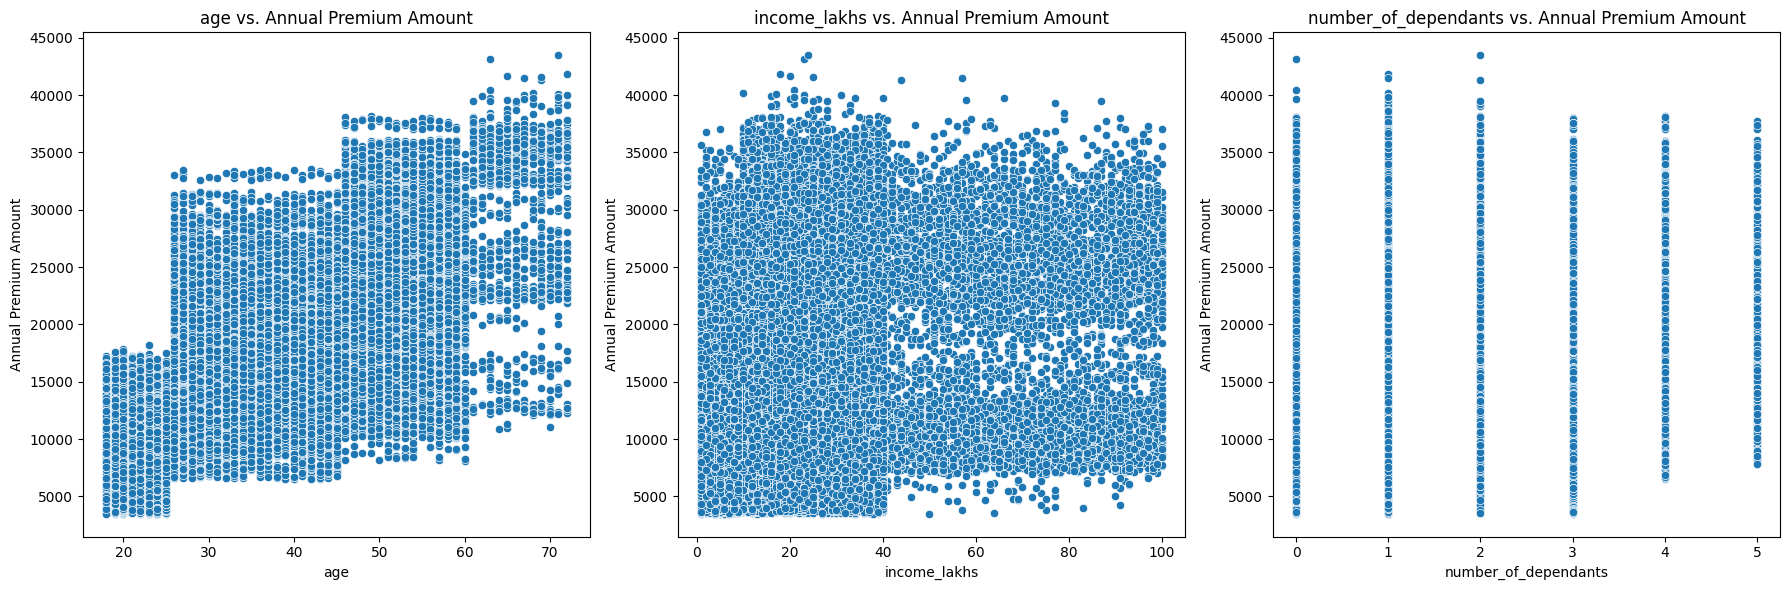

In [209]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

In [210]:
categorical_cols = df.select_dtypes(include=['str']).columns
print(categorical_cols)
len(categorical_cols)

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='str')


9

In [211]:
for col in categorical_cols:
    print(col, ": ", df2[col].unique())

gender :  <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
region :  <ArrowStringArray>
['Northwest', 'Southeast', 'Northeast', 'Southwest']
Length: 4, dtype: str
marital_status :  <ArrowStringArray>
['Unmarried', 'Married']
Length: 2, dtype: str
bmi_category :  <ArrowStringArray>
['Normal', 'Obesity', 'Overweight', 'Underweight']
Length: 4, dtype: str
smoking_status :  <ArrowStringArray>
[    'No Smoking',        'Regular',     'Occasional',      'Smoking=0',
 'Does Not Smoke',    'Not Smoking']
Length: 6, dtype: str
employment_status :  <ArrowStringArray>
['Salaried', 'Self-Employed', 'Freelancer']
Length: 3, dtype: str
income_level :  <ArrowStringArray>
['<10L', '10L - 25L', '> 40L', '25L - 40L']
Length: 4, dtype: str
medical_history :  <ArrowStringArray>
[                           'Diabetes',                 'High blood pressure',
                          'No Disease',      'Diabetes & High blood pressure',
                             'Thyroid',                       

In [212]:
df2.replace({'smoking_status':{
        'Not Smoking': 'No Smoking',
        'Does Not Smoke': 'No Smoking',
        'Smoking=0': 'No Smoking'
}}, inplace=True)

df2['smoking_status'].unique()

<ArrowStringArray>
['No Smoking', 'Regular', 'Occasional']
Length: 3, dtype: str

### Univariate Analysis

In [213]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [214]:
pct_count = df2['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      54.963132
Female    45.036868
Name: proportion, dtype: float64

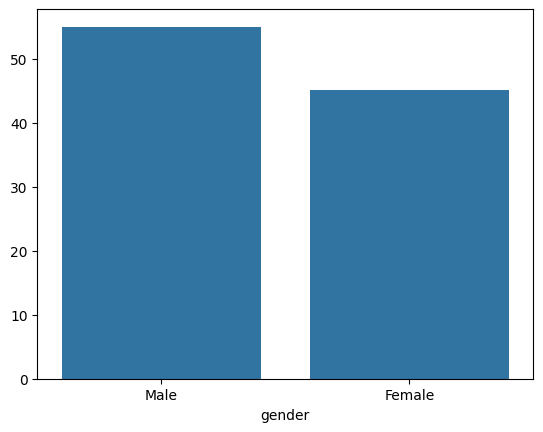

In [215]:
sns.barplot(x=pct_count.index, y=pct_count.values)
plt.show()

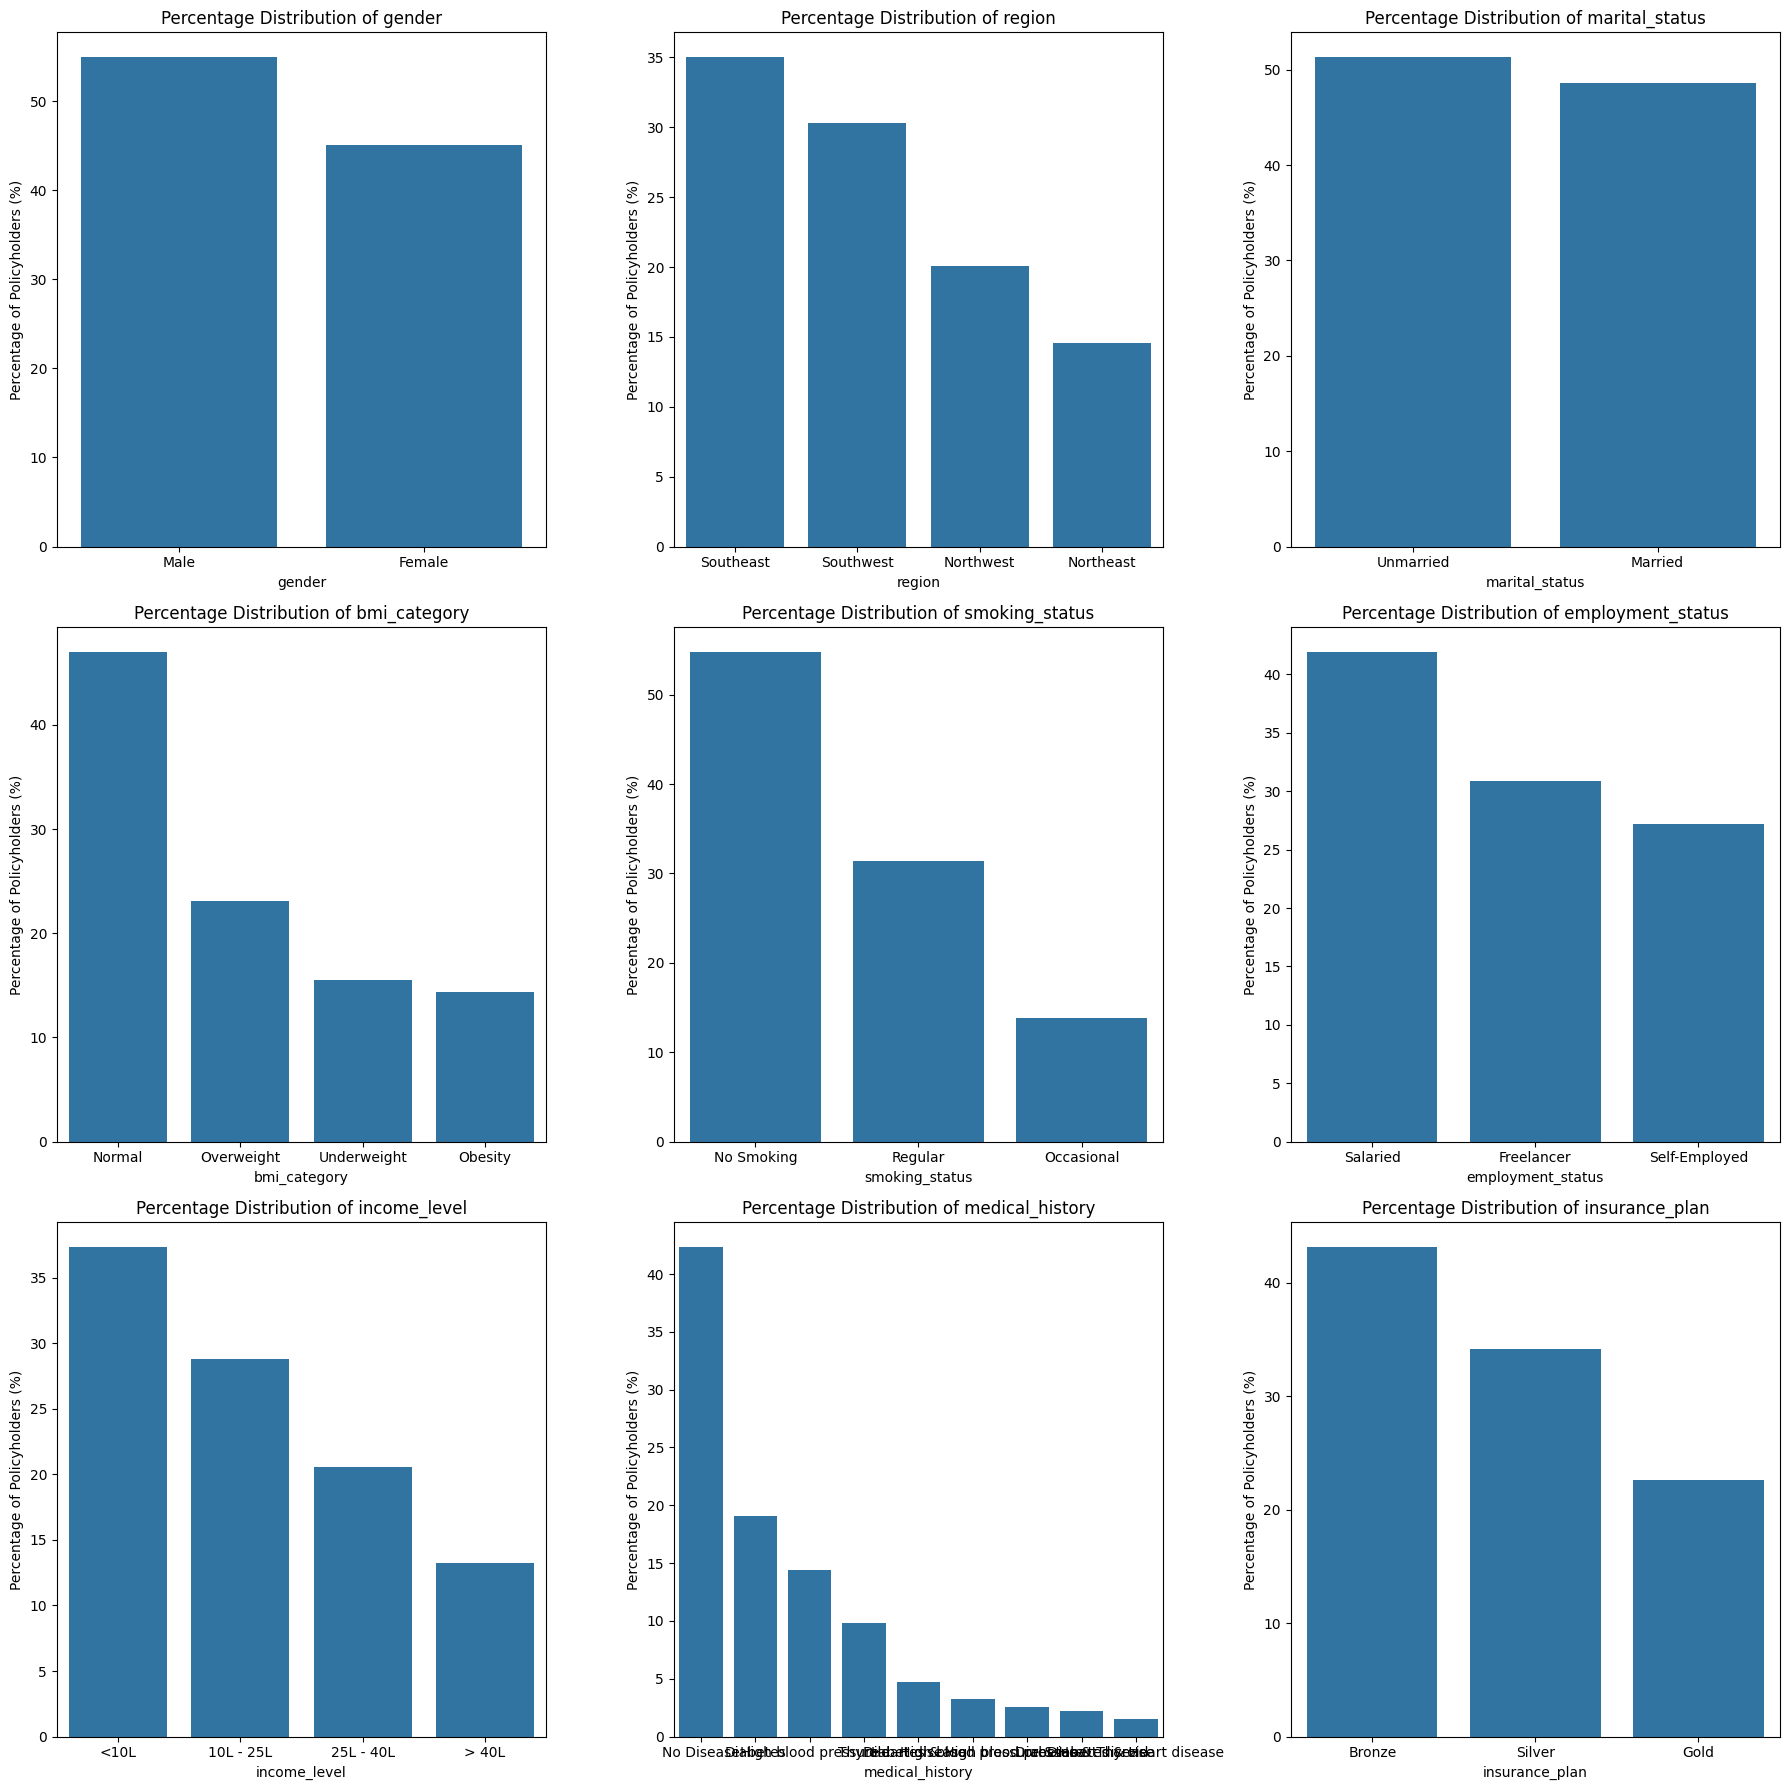

In [216]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

### Bivariate Analysis

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         5307  3880    5182
25L - 40L         3683  2840    3750
<10L             12226   931    5486
> 40L              329  3653    2641


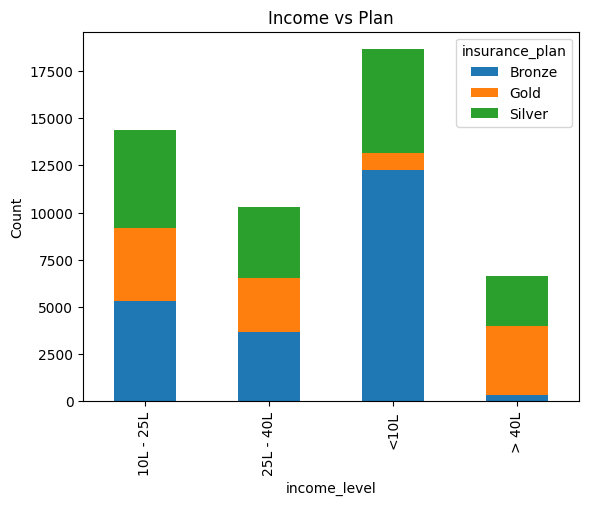

In [217]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

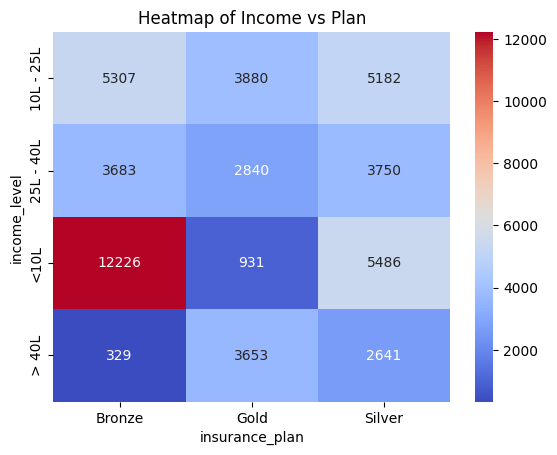

In [218]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

<h2 align="center" style="color:green">Feature Engineering</h2>

In [219]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [220]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [221]:
df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())

,0,1
0,diabetes,NaN
1,diabetes,NaN
2,high blood pressure,NaN
3,no disease,NaN
4,high blood pressure,NaN
...,...,...
49995,no disease,NaN
49996,thyroid,NaN
49997,no disease,NaN
49998,no disease,NaN


### Split medical_history into 'disease1', 'disease2'

In [222]:
df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2[['disease1', 'disease2']].sample(5)

,disease1,disease2
26115,thyroid,NaN
7592,diabetes,NaN
41208,no disease,NaN
4172,diabetes,NaN
6317,diabetes,NaN


In [223]:
# df2['disease1'].fillna("", inplace=True)
# df2['disease2'].fillna("", inplace=True)

df2.fillna({"disease1": "none"}, inplace=True)
df2.fillna({"disease2": "none"}, inplace=True)
df2[['disease1', 'disease2']].sample(5)

,disease1,disease2
8698,no disease,none
31551,high blood pressure,heart disease
7097,high blood pressure,none
30365,no disease,none
7840,no disease,none


In [224]:
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none


### Adding column total_risk_score

In [225]:
df2['total_risk_score'] = 0

In [226]:
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

In [227]:
df2.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score
18237,53,Male,Southeast,Married,3,Overweight,No Smoking,Salaried,<10L,3,High blood pressure,Silver,20531,high blood pressure,none,6
38045,25,Female,Northwest,Unmarried,2,Normal,Regular,Self-Employed,10L - 25L,12,High blood pressure,Bronze,5732,high blood pressure,none,6
4074,60,Male,Southwest,Married,3,Normal,Regular,Self-Employed,10L - 25L,18,Diabetes,Gold,29900,diabetes,none,6
49308,46,Male,Southwest,Married,3,Obesity,Regular,Freelancer,25L - 40L,38,Diabetes & High blood pressure,Silver,27963,diabetes,high blood pressure,12
3565,22,Male,Southwest,Unmarried,0,Normal,Regular,Freelancer,10L - 25L,21,No Disease,Bronze,7130,no disease,none,0


In [228]:
df2.shape

(49908, 16)

In [229]:
df3 = df2.drop(columns=['medical_history', 'disease1', 'disease2'])
df3.head()
df3.shape

(49908, 13)

In [230]:
X = df3.drop(columns=['annual_premium_amount'])
y = df3['annual_premium_amount']

In [231]:
X.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,6
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,6
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,6
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,6


In [232]:
y.head()

0     9053
1    16339
2    18164
3    20303
4    13365
Name: annual_premium_amount, dtype: int64

In [233]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [234]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# 1. Feature groupings
nominal_cols = [
    'gender', 'region', 'marital_status', 
    'bmi_category', 'smoking_status', 'employment_status'
]

# Raw numeric columns (do not include raw string columns here)
numeric_cols = ['age', 'number_of_dependants', 'income_lakhs', 'total_risk_score']

# 2. Category hierarchies
plan_order = ['Bronze', 'Silver', 'Gold']
income_order = ['<10L', '10L - 25L', '25L - 40L', '> 40L']

# 3. Pipelines to encode strings first, then scale numeric outputs
plan_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[plan_order])),
    ('scaler', MinMaxScaler())
])

income_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[income_order])),
    ('scaler', MinMaxScaler())
])

# 4. ColumnTransformer setup
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('plan_pipeline', plan_pipeline, ['insurance_plan']),
        ('income_pipeline', income_pipeline, ['income_level']),
        ('numeric_scaler', MinMaxScaler(), numeric_cols)  # Passed directly without extra brackets
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas')

X_train_processed = preprocessor.fit_transform(X_train)

In [235]:
X_train_processed.head()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,age,number_of_dependants,income_lakhs,total_risk_score
36398,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.5,0.333333,0.370370,0.6,0.090909,0.571429
45560,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.240741,0.8,0.444444,1.000000
23675,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.481481,0.0,0.050505,0.571429
10418,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.481481,0.0,0.030303,0.428571
46227,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.555556,0.0,0.555556,0.428571


In [238]:
X_test_processed = preprocessor.transform(X_test)
X_test_processed

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,age,number_of_dependants,income_lakhs,total_risk_score
24098,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.351852,0.6,0.010101,0.428571
201,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.129630,0.2,0.636364,0.000000
25471,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.074074,0.0,0.010101,0.000000
32500,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.333333,0.148148,0.4,0.202020,0.571429
30832,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.222222,0.2,0.080808,0.357143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12123,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.259259,0.6,0.020202,0.357143
31891,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.666667,0.185185,0.6,0.383838,0.000000
6713,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.5,0.333333,0.481481,0.6,0.232323,0.428571
16957,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.5,0.000000,0.685185,0.2,0.020202,0.857143


In [243]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [245]:
calculate_vif(X_train_processed)

,Column,VIF
0,gender_Male,2.417757
1,region_Northwest,2.109459
2,region_Southeast,2.918877
3,region_Southwest,2.674838
4,marital_status_Unmarried,3.419204
5,bmi_category_Obesity,1.348712
6,bmi_category_Overweight,1.550331
7,bmi_category_Underweight,1.302799
8,smoking_status_Occasional,1.271785
9,smoking_status_Regular,1.769342


In [246]:
X_train_processed_final = X_train_processed.drop(columns=['income_level'])
X_train_processed_final.columns


Index(['gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed',
       'insurance_plan', 'age', 'number_of_dependants', 'income_lakhs',
       'total_risk_score'],
      dtype='str')

In [250]:
X_test_processed = X_test_processed.drop(columns=['income_level'])

<h2 align="center" style="color:green">Model Training</h2>

### LinearRegression

In [253]:
model_lr = LinearRegression()
model_lr.fit(X_train_processed_final, y_train)

test_score = model_lr.score(X_test_processed, y_test)
train_score = model_lr.score(X_train_processed_final, y_train)
print(train_score, test_score)

y_pred = model_lr.predict(X_test_processed)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

mse_lr, rmse_lr


0.9280957176093705 0.9283765993531427


(5056639.130347777, np.float64(2248.697207350909))

In [254]:
model_lr.coef_

array([  121.53023031,   -34.50219135,    27.97504587,   -23.47372614,
        -821.78088646,  3356.07750448,  1613.1421694 ,   364.31350886,
         722.41051531,  2261.97816483,   149.57179545,   378.25130285,
       12515.43782972, 11236.4082633 ,  -536.61172956,  -353.97067084,
        4846.88626348])

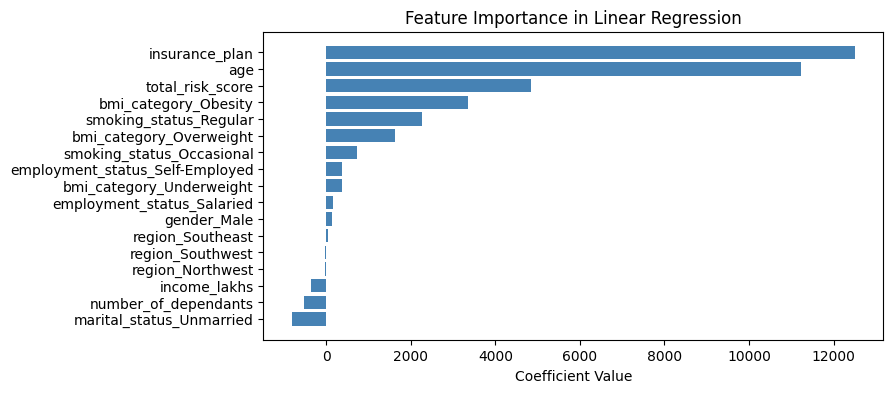

In [255]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_processed_final.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [257]:
from sklearn.linear_model import Ridge

model_reg = Ridge(alpha=1)

model_reg.fit(X_train_processed_final, y_train)

test_score = model_reg.score(X_test_processed, y_test)
train_score = model_reg.score(X_train_processed_final, y_train)
print(train_score, test_score)

y_pred = model_reg.predict(X_test_processed)
mse_reg = mean_squared_error(y_test, y_pred)
rmse_reg = np.sqrt(mse_lr)

mse_reg, rmse_reg

0.9280956798900619 0.9283764905001946


(5056646.815407014, np.float64(2248.698916130618))

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)

model_xgb.fit(X_train_processed_final, y_train)

model_xgb.fit(X_train_processed_final, y_train)
model_xgb.score(X_test_processed, y_test)

0.9781450033187866

In [259]:
y_pred = model_xgb.predict(X_test_processed)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)

mse_xgb, rmse_xgb

(1542969.5, np.float64(1242.1632340397134))

In [261]:
model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train_processed_final, y_train)
random_search.best_score_

np.float64(0.9810734589894613)

In [262]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [265]:
best_model = random_search.best_estimator_

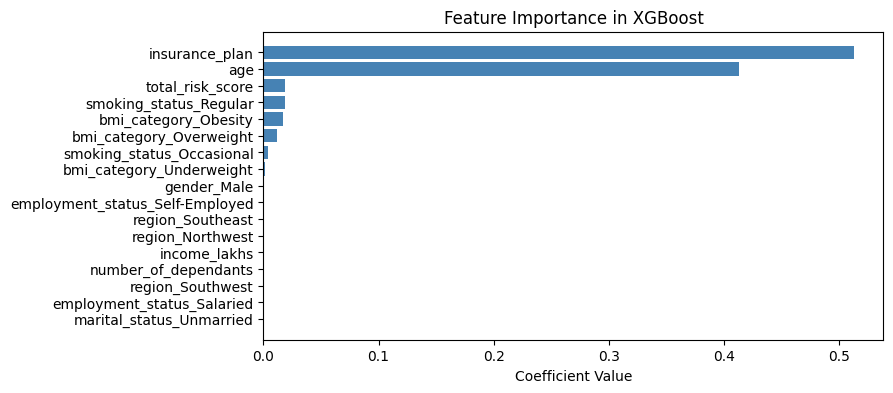

In [266]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_processed_final.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [267]:
y_pred = best_model.predict(X_test_processed)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
24098,9246,9547.453125,301.453125,3.260363
201,11664,13488.259766,1824.259766,15.640087
25471,10472,7417.219727,-3054.780273,-29.170935
32500,26267,25508.873047,-758.126953,-2.886233
30832,9106,9547.453125,441.453125,4.847937


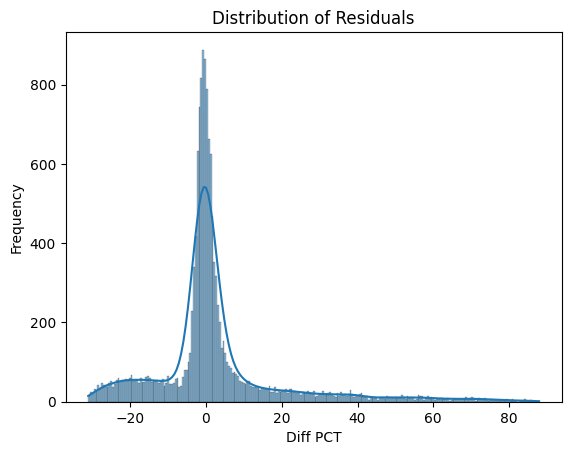

In [268]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [270]:
X_test_processed.shape

(14973, 17)

In [269]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
201,11664,13488.259766,1824.259766,15.640087
25471,10472,7417.219727,-3054.780273,-29.170935
47939,11996,13450.725586,1454.725586,12.126755
26239,4436,6649.229492,2213.229492,49.892459
16907,8952,10888.099609,1936.099609,21.627565


In [271]:
extreme_results_df.shape

(4466, 4)

In [272]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

29.827021972884527

We have 30% extreme errors which means for 30% customers we will either overcharge or undercharge by 10% or more

In [273]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
25207,3501,6578.916016,3077.916016,87.915339
29904,3503,6578.916016,3075.916016,87.808051
48801,3516,6578.916016,3062.916016,87.113652
10288,3517,6578.916016,3061.916016,87.060450
23975,3520,6578.916016,3058.916016,86.901023
...,...,...,...,...
17089,4960,7456.396484,2496.396484,50.330574
14376,4887,7345.736816,2458.736816,50.311783
4067,4846,7276.824707,2430.824707,50.161467
23368,4360,6544.921875,2184.921875,50.112887


There will be about 549 customers whom we will overcharge or underchage by more than 50%

In [274]:
extreme_errors_df = X_test_processed.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,age,number_of_dependants,income_lakhs,total_risk_score
201,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.129630,0.2,0.636364,0.0
25471,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.074074,0.0,0.010101,0.0


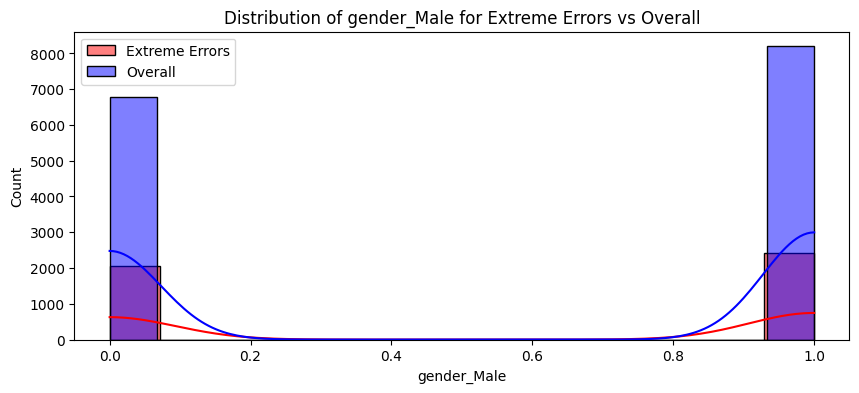

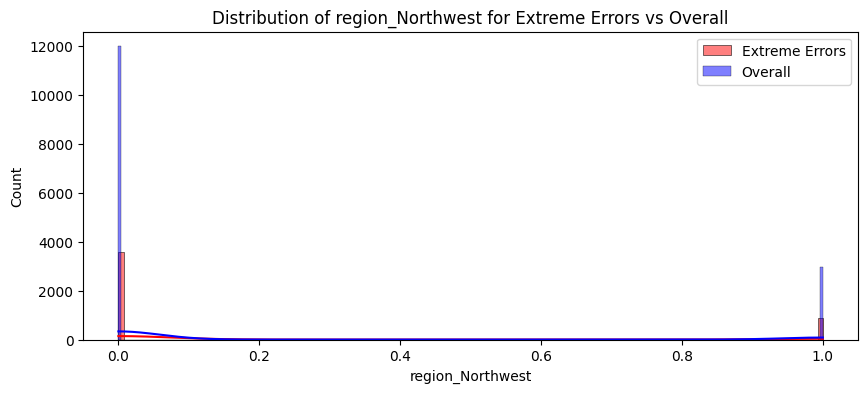

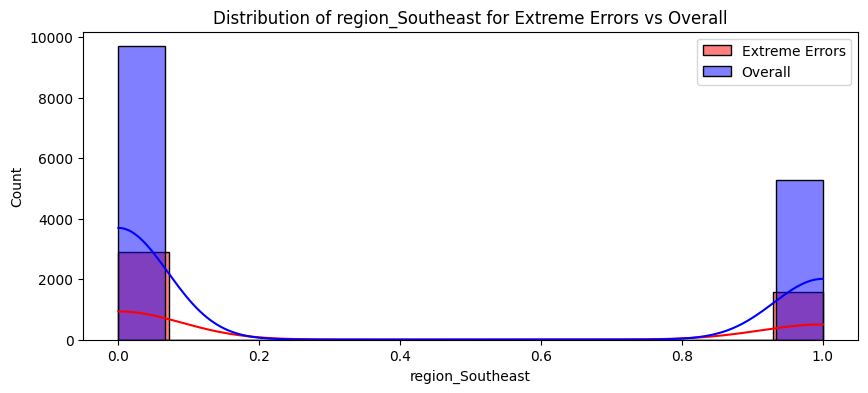

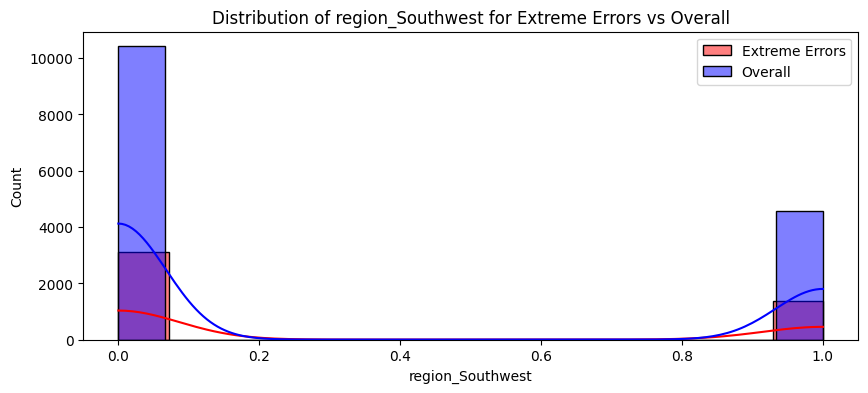

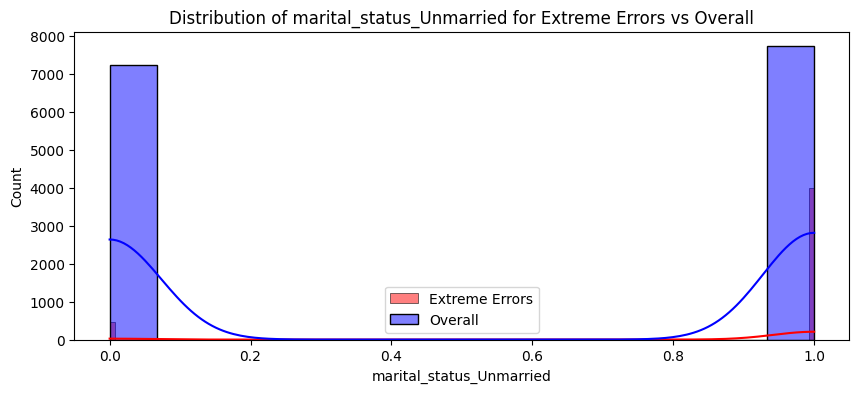

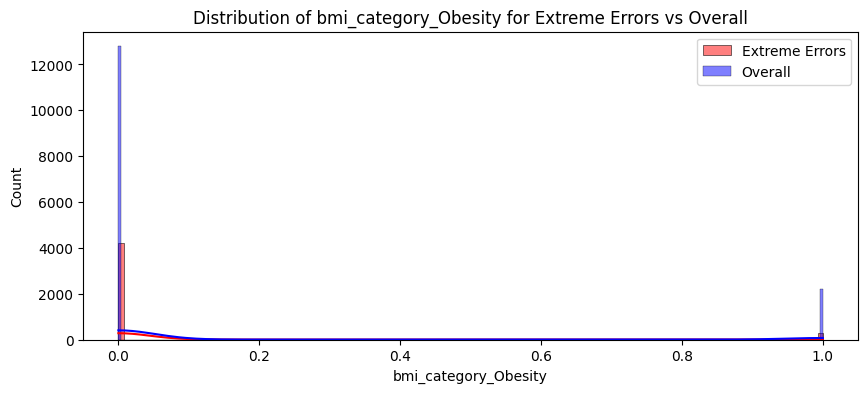

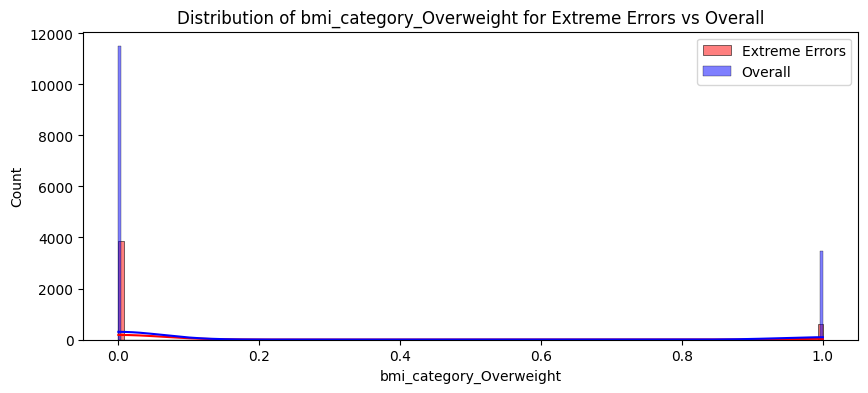

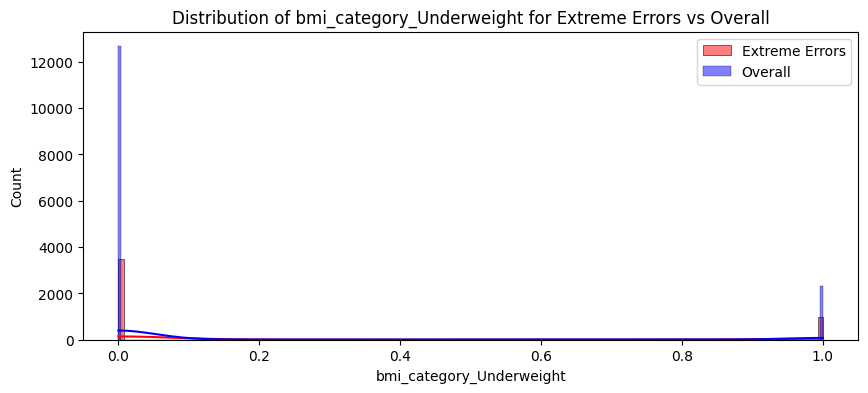

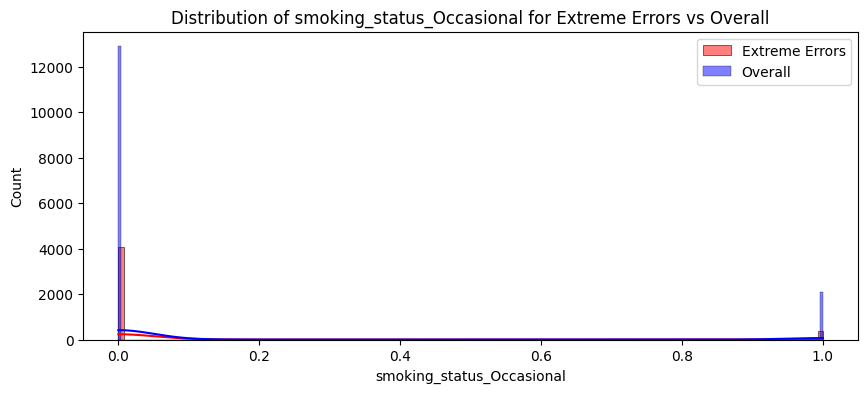

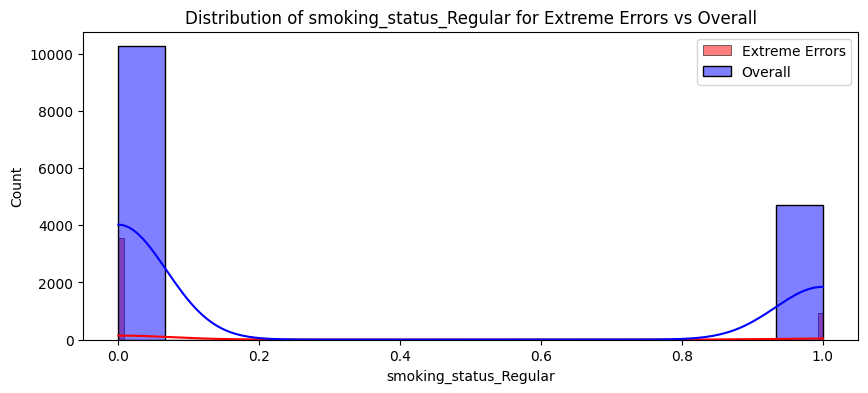

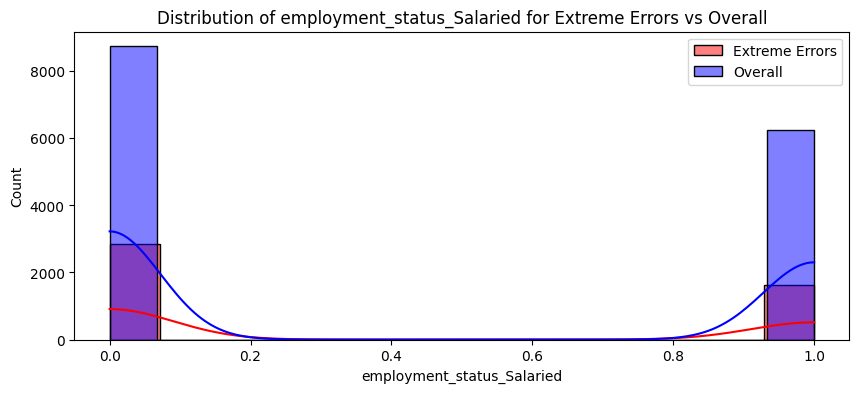

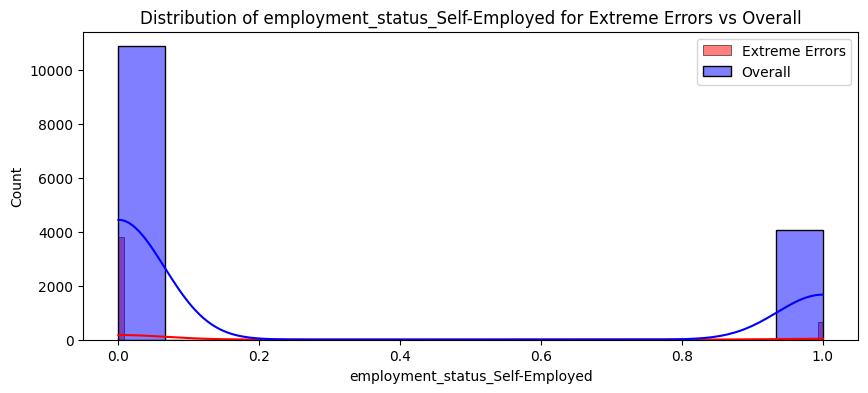

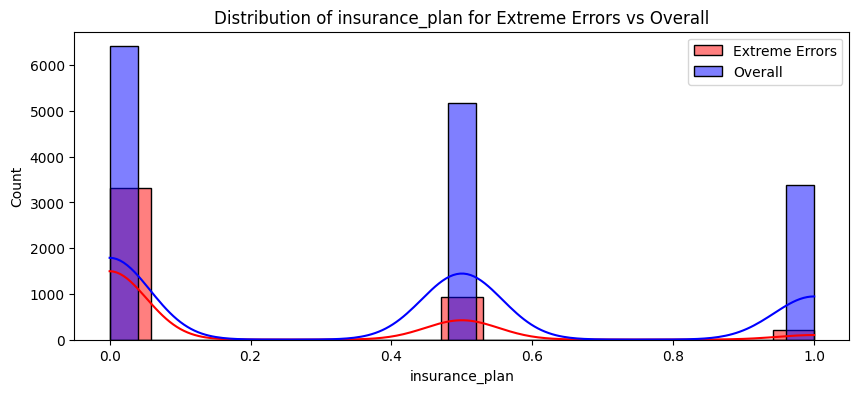

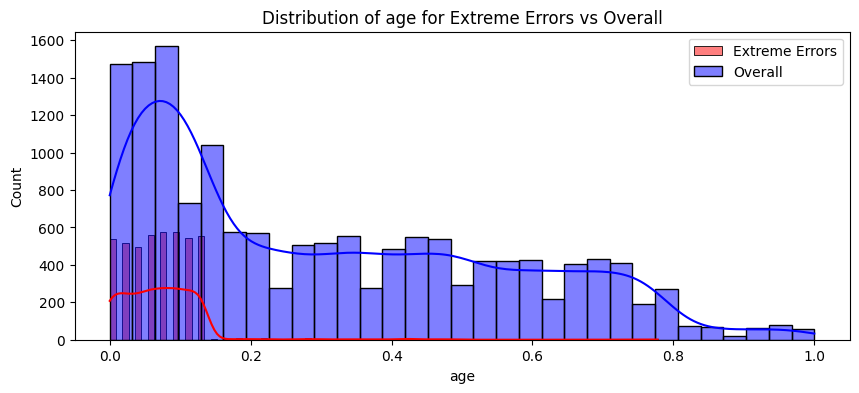

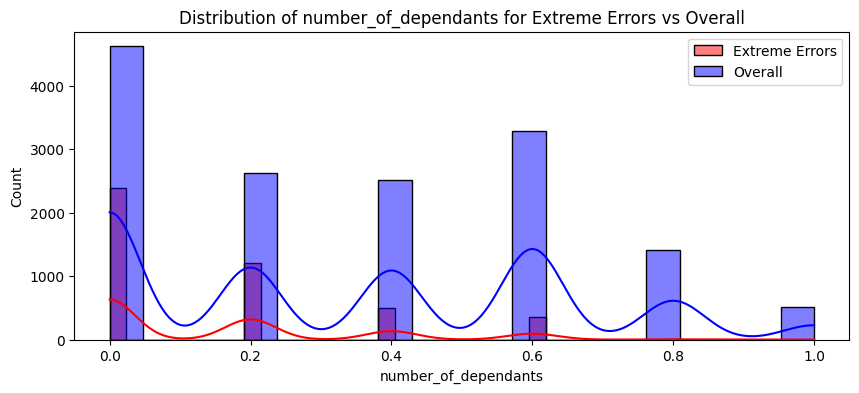

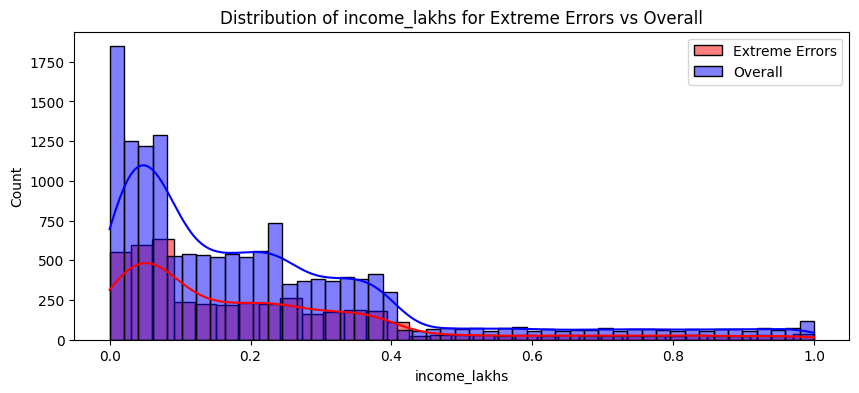

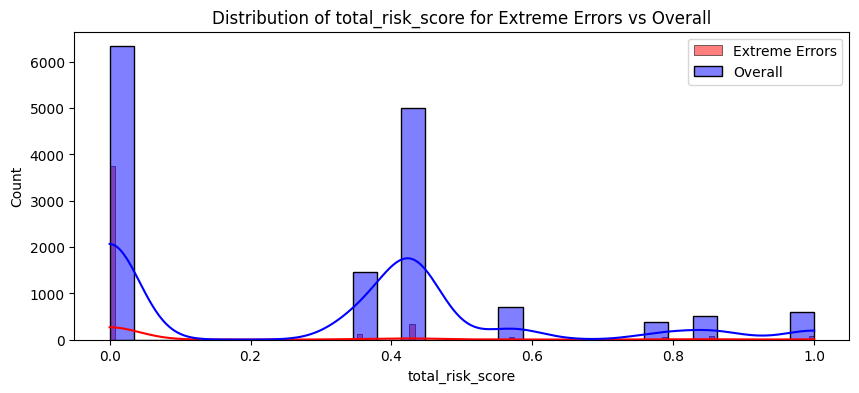

In [276]:
for feature in X_test_processed.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test_processed[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [277]:
extreme_errors_df['income_level']=-1

In [280]:
# Create a copy so you keep the rest of the columns intact
df_reversed = extreme_errors_df.copy()

# 1. Retrieve the fitted scaler from the ColumnTransformer
scaler = preprocessor.named_transformers_['numeric_scaler']

# 2. Inverse-transform only the numeric columns
df_reversed[numeric_cols] = scaler.inverse_transform(extreme_errors_df[numeric_cols])

df_reversed.head()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,age,number_of_dependants,income_lakhs,total_risk_score,income_level
201,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,25.0,1.0,64.0,0.0,-1
25471,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,22.0,0.0,2.0,0.0,-1
47939,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,24.0,0.0,43.0,0.0,-1
26239,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,30.0,0.0,-1
16907,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.5,24.0,0.0,61.0,0.0,-1


<Axes: xlabel='age', ylabel='Count'>

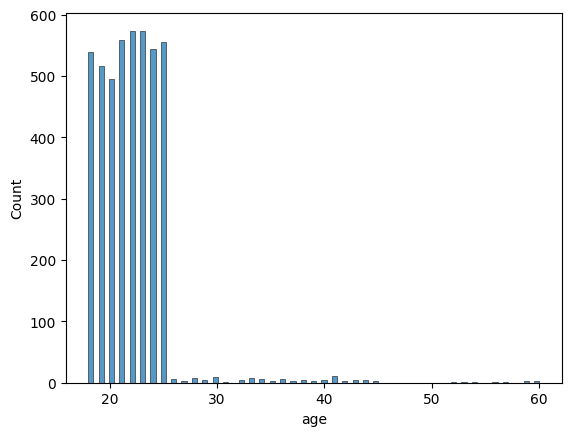

In [281]:
sns.histplot(df_reversed.age)